# Business Problem

The global live entertainment industry has experienced significant changes over the past decade due to changing audience preferences, dynamic pricing strategies, artist popularity, and the COVID-19 pandemic. Concert organizers need data-driven insights to optimize ticket pricing, forecast attendance, maximize revenue, and improve event planning.

This project aims to analyze historical concert data from 2016–2026 to understand the key factors influencing concert performance and build machine learning models capable of predicting ticket prices and business outcomes.

# Business Objectives
Business Objectives
Understand the factors influencing concert attendance.
Analyze the impact of artist popularity on concert demand.
Study the relationship between ticket pricing and festival characteristics.
Evaluate the impact of COVID-19 on the live entertainment industry.
Identify major revenue drivers across artists, festivals, genres, and countries.
Build predictive models to estimate concert ticket prices.

# Dataset Overview

The dataset contains 20,000 concert records spanning 2016–2026 across multiple countries and music festivals.

It consists of 69 features describing artists, venues, ticket pricing, attendance, weather conditions, revenues, and event characteristics.

# Key Variables
| Feature                  | Description                |
| ------------------------ | -------------------------- |
| artist                   | Performing Artist          |
| primary_genre            | Primary music genre        |
| followers_millions       | Artist popularity          |
| spotify_popularity       | Spotify popularity score   |
| attendance               | Number of attendees        |
| capacity                 | Venue capacity             |
| sellout_pct              | Percentage of tickets sold |
| average_ticket_price_usd | Average ticket price       |
| festival_tier            | Festival premium level     |
| billing_status           | Headliner / Support Act    |
| weather_type             | Weather during event       |
| total_revenue_usd        | Total event revenue        |
| profit_usd               | Estimated event profit     |
| year                     | Event year                 |

# Project Workflow
Data Understanding
        ↓
Data Quality Assessment
        ↓
Exploratory Data Analysis
        ↓
Feature Engineering
        ↓
Data Preprocessing
        ↓
Model Development
        ↓
Model Evaluation
        ↓
Business Recommendations

Note: This project uses a realistically simulated concert dataset created for educational and portfolio purposes. While the data closely resembles real-world concert economics, it should not be interpreted as actual financial or operational records of any artist, festival, or organization.

# Phase 1 — Data Understanding

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [4]:
df = pd.read_csv(r"spotify_concert_demand_dataset.csv")

# Dataset Overview & Initial Inspection

In [5]:
df.head()

,artist,artist_country,record_label,artist_age,primary_genre,secondary_genre,multi_genre_artist,spotify_popularity,followers_millions,monthly_listeners_millions,...,sponsor_revenue_usd,advertising_revenue_usd,attendance,sellout_pct,occupancy_pct,avg_spend_per_customer_usd,total_revenue_usd,profit_usd,average_ticket_price_usd,competing_concerts_same_city_week
0,Boygenius,USA,NaN,27.0,Alternative Pop,Indie Rock,Yes,19,4.4,3.2,...,38631.49,18736.29,3804,53.5,53.5,63.65,502614.84,190337.59,93.39,1
1,Bonobo,NaN,Independent,NaN,EDM,Downtempo,Yes,60,13.7,12.6,...,515328.15,241142.19,81447,100.0,100.0,89.10,22853464.95,6555703.52,249.68,1
2,Robin Schulz,Germany,NaN,35.0,EDM,Tropical House,Yes,53,10.3,7.9,...,185478.41,41682.27,62954,91.2,86.1,114.95,12300605.62,4008260.29,170.00,4
3,Morgan Wallen,USA,Universal,26.0,Country,Country Pop,Yes,40,14.1,8.4,...,24383.73,9081.63,10240,65.9,61.6,73.57,1814949.72,604707.96,144.85,1
4,Gorgon City,UK,NaN,41.0,EDM,House,Yes,35,2.8,1.9,...,533517.96,143508.01,25979,32.8,30.8,50.66,3166126.70,1289886.74,69.10,0


In [6]:
df.tail()

,artist,artist_country,record_label,artist_age,primary_genre,secondary_genre,multi_genre_artist,spotify_popularity,followers_millions,monthly_listeners_millions,...,sponsor_revenue_usd,advertising_revenue_usd,attendance,sellout_pct,occupancy_pct,avg_spend_per_customer_usd,total_revenue_usd,profit_usd,average_ticket_price_usd,competing_concerts_same_city_week
19995,Bryson Tiller,USA,Sony,32.0,R&B,Trapsoul,Yes,55,12.3,9.5,...,196604.39,62508.82,16018,65.1,63.1,81.84,3015919.06,788264.22,148.36,0
19996,CamelPhat,UK,NaN,37.0,EDM,Tech House,Yes,47,11.3,6.7,...,110467.53,31626.44,17382,73.2,68.4,37.50,2165481.28,593717.50,94.31,0
19997,Cloonee,NaN,NaN,NaN,EDM,Tech House,Yes,27,4.5,3.2,...,217524.53,69416.03,43868,71.4,70.2,61.57,5652265.01,1668484.55,104.11,5
19998,Bryson Tiller,USA,Sony,27.0,R&B,Trapsoul,Yes,38,7.9,6.5,...,1112756.01,420085.67,92186,60.9,58.4,71.60,13875821.73,4490634.31,100.59,0
19999,Flux Pavilion,UK,NaN,34.0,EDM,Dubstep,Yes,52,11.4,8.9,...,19139.88,6852.27,1804,67.9,68.1,93.89,349782.12,123209.20,155.34,6


In [7]:
df.sample(5)

,artist,artist_country,record_label,artist_age,primary_genre,secondary_genre,multi_genre_artist,spotify_popularity,followers_millions,monthly_listeners_millions,...,sponsor_revenue_usd,advertising_revenue_usd,attendance,sellout_pct,occupancy_pct,avg_spend_per_customer_usd,total_revenue_usd,profit_usd,average_ticket_price_usd,competing_concerts_same_city_week
17563,Future,USA,Sony,35.0,Hip Hop,Trap,Yes,24,7.3,4.4,...,112281.41,30215.89,13602,54.9,60.0,71.46,2042391.67,792413.89,114.29,2
8402,Calvin Harris,UK,Sony,40.0,EDM,House,Yes,93,41.3,27.1,...,197970.57,73930.60,15457,78.4,73.7,152.38,5263467.77,1261123.67,300.90,0
4892,Big Gigantic,NaN,NaN,NaN,EDM,Livetronica,Yes,37,4.9,3.6,...,94445.20,37317.32,15073,58.6,56.9,75.87,2180922.71,812559.22,117.53,3
5929,Dimitri Vegas & Like Mike,Belgium,NaN,34.0,EDM,Big Room,Yes,31,14.1,11.4,...,882623.06,258520.31,38264,35.9,36.6,73.82,9274218.72,2138937.71,183.52,2
8124,Frank Ocean,USA,Universal,38.0,R&B,Alternative R&B,Yes,89,18.5,11.7,...,534961.07,259400.85,53748,68.8,73.8,70.62,8259241.00,2604446.91,110.78,7


In [8]:
df.shape

(20000, 69)

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
artist_age,15283.0,3.412641e+01,9.086303e+00,12.00,28.0000,33.000,3.900000e+01,64.00
spotify_popularity,20000.0,4.608305e+01,2.187354e+01,15.00,28.0000,43.000,6.100000e+01,100.00
followers_millions,20000.0,1.126120e+01,8.468808e+00,0.20,4.7000,9.100,1.530000e+01,44.90
monthly_listeners_millions,20000.0,8.166535e+00,6.417774e+00,0.10,3.3000,6.500,1.110000e+01,37.20
total_streams_billions,20000.0,1.994875e+00,1.652014e+00,0.05,0.7800,1.530,2.710000e+00,11.07
years_active,20000.0,9.031050e+00,4.498688e+00,1.00,6.0000,9.000,1.200000e+01,22.00
grammy_winner,20000.0,1.816000e-01,3.855242e-01,0.00,0.0000,0.000,0.000000e+00,1.00
instagram_followers_millions,20000.0,1.078530e+01,8.498068e+00,0.20,4.5000,8.400,1.500000e+01,55.70
tiktok_followers_millions,20000.0,1.112740e+01,9.491449e+00,0.10,4.3000,8.250,1.490000e+01,66.60
youtube_subscribers_millions,20000.0,9.534725e+00,7.673140e+00,0.10,3.9000,7.400,1.270000e+01,46.40


Interpretations :-The average performing artist is approximately 34 years old with a median career span of 9 years, indicating that most concerts in the dataset feature well-established rather than newly emerging artists.The average ticket price of approximately $136 suggests that the dataset primarily represents medium-to-premium concert events rather than local community performances. indicating that ticket pricing decisions can have a substantial financial impact on event profitability. It is also being observed that the average Concert Ticket Price is around 136 USD ranging from 13.6 to 470 USD. It is also worth noting that the Average Revenue is around 2.26 Million USD but the Average Profit is actually sitting around 700k per concert indicating that around 1.56 Million USD is being used for the Artists Bookings and other Logistics per concert. 

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 69 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   artist                             20000 non-null  object 
 1   artist_country                     15283 non-null  object 
 2   record_label                       8539 non-null   object 
 3   artist_age                         15283 non-null  float64
 4   primary_genre                      20000 non-null  object 
 5   secondary_genre                    20000 non-null  object 
 6   multi_genre_artist                 20000 non-null  object 
 7   spotify_popularity                 20000 non-null  int64  
 8   followers_millions                 20000 non-null  float64
 9   monthly_listeners_millions         20000 non-null  float64
 10  total_streams_billions             20000 non-null  float64
 11  years_active                       20000 non-null  int

Interpretations :- artist_country, record_label, artist_age column contains null values, These features require further investigation to determine whether the missing values occur randomly or follow a systematic pattern before deciding on an appropriate imputation strategy.

In [11]:
df.describe(include='object').T

,count,unique,top,freq
artist,20000,216,Ace Aura,119
artist_country,15283,23,USA,5628
record_label,8539,4,Universal,4462
primary_genre,20000,13,EDM,12139
secondary_genre,20000,71,Techno,1594
multi_genre_artist,20000,2,Yes,19906
event_type,20000,4,Festival,10974
event_status,20000,2,Held,19265
festival_name,20000,113,Standalone Show,9026
is_headliner,20000,2,Yes,13244


Interpretation :- The Dataset tells us that USA has the highest frequency and Sunday is the most frequently occurring event day in the dataset. One possible explanation is since Highest Footfall will be observed during the Weekends.

Key Takeaways

• Dataset contains 20,000 observations across 69 features.

• Most numerical variables appear to have reasonable ranges.

• Several categorical attributes contain missing values requiring further assessment.

• The dataset contains rich information spanning artist, venue, pricing, weather and financial metrics.

• Initial inspection suggests the dataset is suitable for predictive modelling

# Data Quality Assessment

In [12]:
duplicate_values = df.duplicated().sum()
print(duplicate_values)

0


In [13]:
df.isnull().any()

artist                               False
artist_country                        True
record_label                          True
artist_age                            True
primary_genre                        False
                                     ...  
avg_spend_per_customer_usd           False
total_revenue_usd                    False
profit_usd                           False
average_ticket_price_usd             False
competing_concerts_same_city_week    False
Length: 69, dtype: bool

In [14]:
df[df['artist_country'].isnull()]

,artist,artist_country,record_label,artist_age,primary_genre,secondary_genre,multi_genre_artist,spotify_popularity,followers_millions,monthly_listeners_millions,...,sponsor_revenue_usd,advertising_revenue_usd,attendance,sellout_pct,occupancy_pct,avg_spend_per_customer_usd,total_revenue_usd,profit_usd,average_ticket_price_usd,competing_concerts_same_city_week
1,Bonobo,NaN,Independent,NaN,EDM,Downtempo,Yes,60,13.7,12.6,...,515328.15,241142.19,81447,100.0,100.0,89.10,22853464.95,6555703.52,249.68,1
11,MEDUZA x Becky Hill,NaN,NaN,NaN,EDM,House,Yes,15,1.3,1.1,...,226343.07,93479.75,15614,36.3,33.2,46.83,1774413.73,480808.03,65.38,1
17,Marsh,NaN,NaN,NaN,EDM,Deep House,Yes,15,1.8,1.3,...,10315.55,2256.75,3773,28.1,26.4,50.63,321595.06,135915.13,51.42,1
18,Jauz,NaN,NaN,NaN,EDM,Bass House,Yes,37,5.9,3.4,...,51072.33,15508.68,7038,60.0,57.9,70.61,1066549.34,266128.90,120.12,6
24,ODESZA,NaN,NaN,NaN,EDM,Chillwave,Yes,74,16.4,12.4,...,1095030.67,404382.63,61728,44.5,47.6,62.98,10126896.34,3437705.20,106.91,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19983,Amelie Lens B2B Charlotte de Witte,NaN,NaN,NaN,EDM,Techno,Yes,19,2.0,1.8,...,214943.65,85422.22,109845,75.3,72.7,43.71,15346132.36,4927624.27,112.90,1
19984,Acraze,NaN,NaN,NaN,EDM,House,Yes,15,1.8,1.0,...,6017.30,1459.44,553,36.8,34.9,39.25,66414.16,29627.64,70.93,0
19985,Recondite,NaN,NaN,NaN,EDM,Melodic Techno,Yes,15,1.3,0.7,...,30044.29,8314.15,2590,36.7,31.9,61.58,297348.33,104588.48,80.26,0
19986,Vini Vici,NaN,NaN,NaN,EDM,Psytrance,Yes,35,4.8,2.5,...,114630.27,28266.61,8337,44.8,45.0,40.83,849256.34,197170.74,54.53,1


In [15]:
df[df['record_label'].isnull()]

,artist,artist_country,record_label,artist_age,primary_genre,secondary_genre,multi_genre_artist,spotify_popularity,followers_millions,monthly_listeners_millions,...,sponsor_revenue_usd,advertising_revenue_usd,attendance,sellout_pct,occupancy_pct,avg_spend_per_customer_usd,total_revenue_usd,profit_usd,average_ticket_price_usd,competing_concerts_same_city_week
0,Boygenius,USA,NaN,27.0,Alternative Pop,Indie Rock,Yes,19,4.4,3.2,...,38631.49,18736.29,3804,53.5,53.5,63.65,502614.84,190337.59,93.39,1
2,Robin Schulz,Germany,NaN,35.0,EDM,Tropical House,Yes,53,10.3,7.9,...,185478.41,41682.27,62954,91.2,86.1,114.95,12300605.62,4008260.29,170.00,4
4,Gorgon City,UK,NaN,41.0,EDM,House,Yes,35,2.8,1.9,...,533517.96,143508.01,25979,32.8,30.8,50.66,3166126.70,1289886.74,69.10,0
6,Chris Stussy,Netherlands,NaN,31.0,EDM,Tech House,Yes,36,3.9,3.0,...,28525.50,8712.35,2079,31.0,34.4,63.67,272336.40,107802.09,97.83,1
8,Phoebe Bridgers,USA,NaN,31.0,Alternative Pop,Indie Folk,Yes,45,14.3,9.7,...,65922.36,22240.17,6614,60.3,62.0,108.34,1462261.46,506517.40,178.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19992,John Summit,USA,NaN,28.0,EDM,Tech House,Yes,65,22.0,13.3,...,276513.17,94328.38,33233,59.0,63.6,71.56,6343434.15,1576140.26,153.96,1
19993,Flosstradamus,USA,NaN,41.0,EDM,Trap,Yes,43,2.8,2.4,...,217096.37,78225.71,34466,57.5,56.2,64.25,6089531.74,2260121.40,154.90,1
19996,CamelPhat,UK,NaN,37.0,EDM,Tech House,Yes,47,11.3,6.7,...,110467.53,31626.44,17382,73.2,68.4,37.50,2165481.28,593717.50,94.31,0
19997,Cloonee,NaN,NaN,NaN,EDM,Tech House,Yes,27,4.5,3.2,...,217524.53,69416.03,43868,71.4,70.2,61.57,5652265.01,1668484.55,104.11,5


In [16]:
df[df['artist_age'].isnull()]

,artist,artist_country,record_label,artist_age,primary_genre,secondary_genre,multi_genre_artist,spotify_popularity,followers_millions,monthly_listeners_millions,...,sponsor_revenue_usd,advertising_revenue_usd,attendance,sellout_pct,occupancy_pct,avg_spend_per_customer_usd,total_revenue_usd,profit_usd,average_ticket_price_usd,competing_concerts_same_city_week
1,Bonobo,NaN,Independent,NaN,EDM,Downtempo,Yes,60,13.7,12.6,...,515328.15,241142.19,81447,100.0,100.0,89.10,22853464.95,6555703.52,249.68,1
11,MEDUZA x Becky Hill,NaN,NaN,NaN,EDM,House,Yes,15,1.3,1.1,...,226343.07,93479.75,15614,36.3,33.2,46.83,1774413.73,480808.03,65.38,1
17,Marsh,NaN,NaN,NaN,EDM,Deep House,Yes,15,1.8,1.3,...,10315.55,2256.75,3773,28.1,26.4,50.63,321595.06,135915.13,51.42,1
18,Jauz,NaN,NaN,NaN,EDM,Bass House,Yes,37,5.9,3.4,...,51072.33,15508.68,7038,60.0,57.9,70.61,1066549.34,266128.90,120.12,6
24,ODESZA,NaN,NaN,NaN,EDM,Chillwave,Yes,74,16.4,12.4,...,1095030.67,404382.63,61728,44.5,47.6,62.98,10126896.34,3437705.20,106.91,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19983,Amelie Lens B2B Charlotte de Witte,NaN,NaN,NaN,EDM,Techno,Yes,19,2.0,1.8,...,214943.65,85422.22,109845,75.3,72.7,43.71,15346132.36,4927624.27,112.90,1
19984,Acraze,NaN,NaN,NaN,EDM,House,Yes,15,1.8,1.0,...,6017.30,1459.44,553,36.8,34.9,39.25,66414.16,29627.64,70.93,0
19985,Recondite,NaN,NaN,NaN,EDM,Melodic Techno,Yes,15,1.3,0.7,...,30044.29,8314.15,2590,36.7,31.9,61.58,297348.33,104588.48,80.26,0
19986,Vini Vici,NaN,NaN,NaN,EDM,Psytrance,Yes,35,4.8,2.5,...,114630.27,28266.61,8337,44.8,45.0,40.83,849256.34,197170.74,54.53,1


In [17]:
df.isnull().sum()

artist                                   0
artist_country                        4717
record_label                         11461
artist_age                            4717
primary_genre                            0
                                     ...  
avg_spend_per_customer_usd               0
total_revenue_usd                        0
profit_usd                               0
average_ticket_price_usd                 0
competing_concerts_same_city_week        0
Length: 69, dtype: int64

In [18]:
(df.isnull().sum()/len(df) *100).sort_values(ascending=False)

record_label                         57.305
artist_age                           23.585
artist_country                       23.585
artist                                0.000
primary_genre                         0.000
                                      ...  
avg_spend_per_customer_usd            0.000
total_revenue_usd                     0.000
profit_usd                            0.000
average_ticket_price_usd              0.000
competing_concerts_same_city_week     0.000
Length: 69, dtype: float64

As per the Dataset record_label column contains the highest amount of null values. It might also indicate that some of the artists from our dataset might not have any signed Records Label also the Dataset Indicates that the Artist Country and Age have similar null values.The missing values may indicate unavailable metadata or genuinely unknown information. Further investigation is required before deciding on an imputation strategy.

In [20]:
df[df['artist_country'].isnull()].isnull().sum()

artist                                  0
artist_country                       4717
record_label                         4627
artist_age                           4717
primary_genre                           0
                                     ... 
avg_spend_per_customer_usd              0
total_revenue_usd                       0
profit_usd                              0
average_ticket_price_usd                0
competing_concerts_same_city_week       0
Length: 69, dtype: int64

<Axes: >

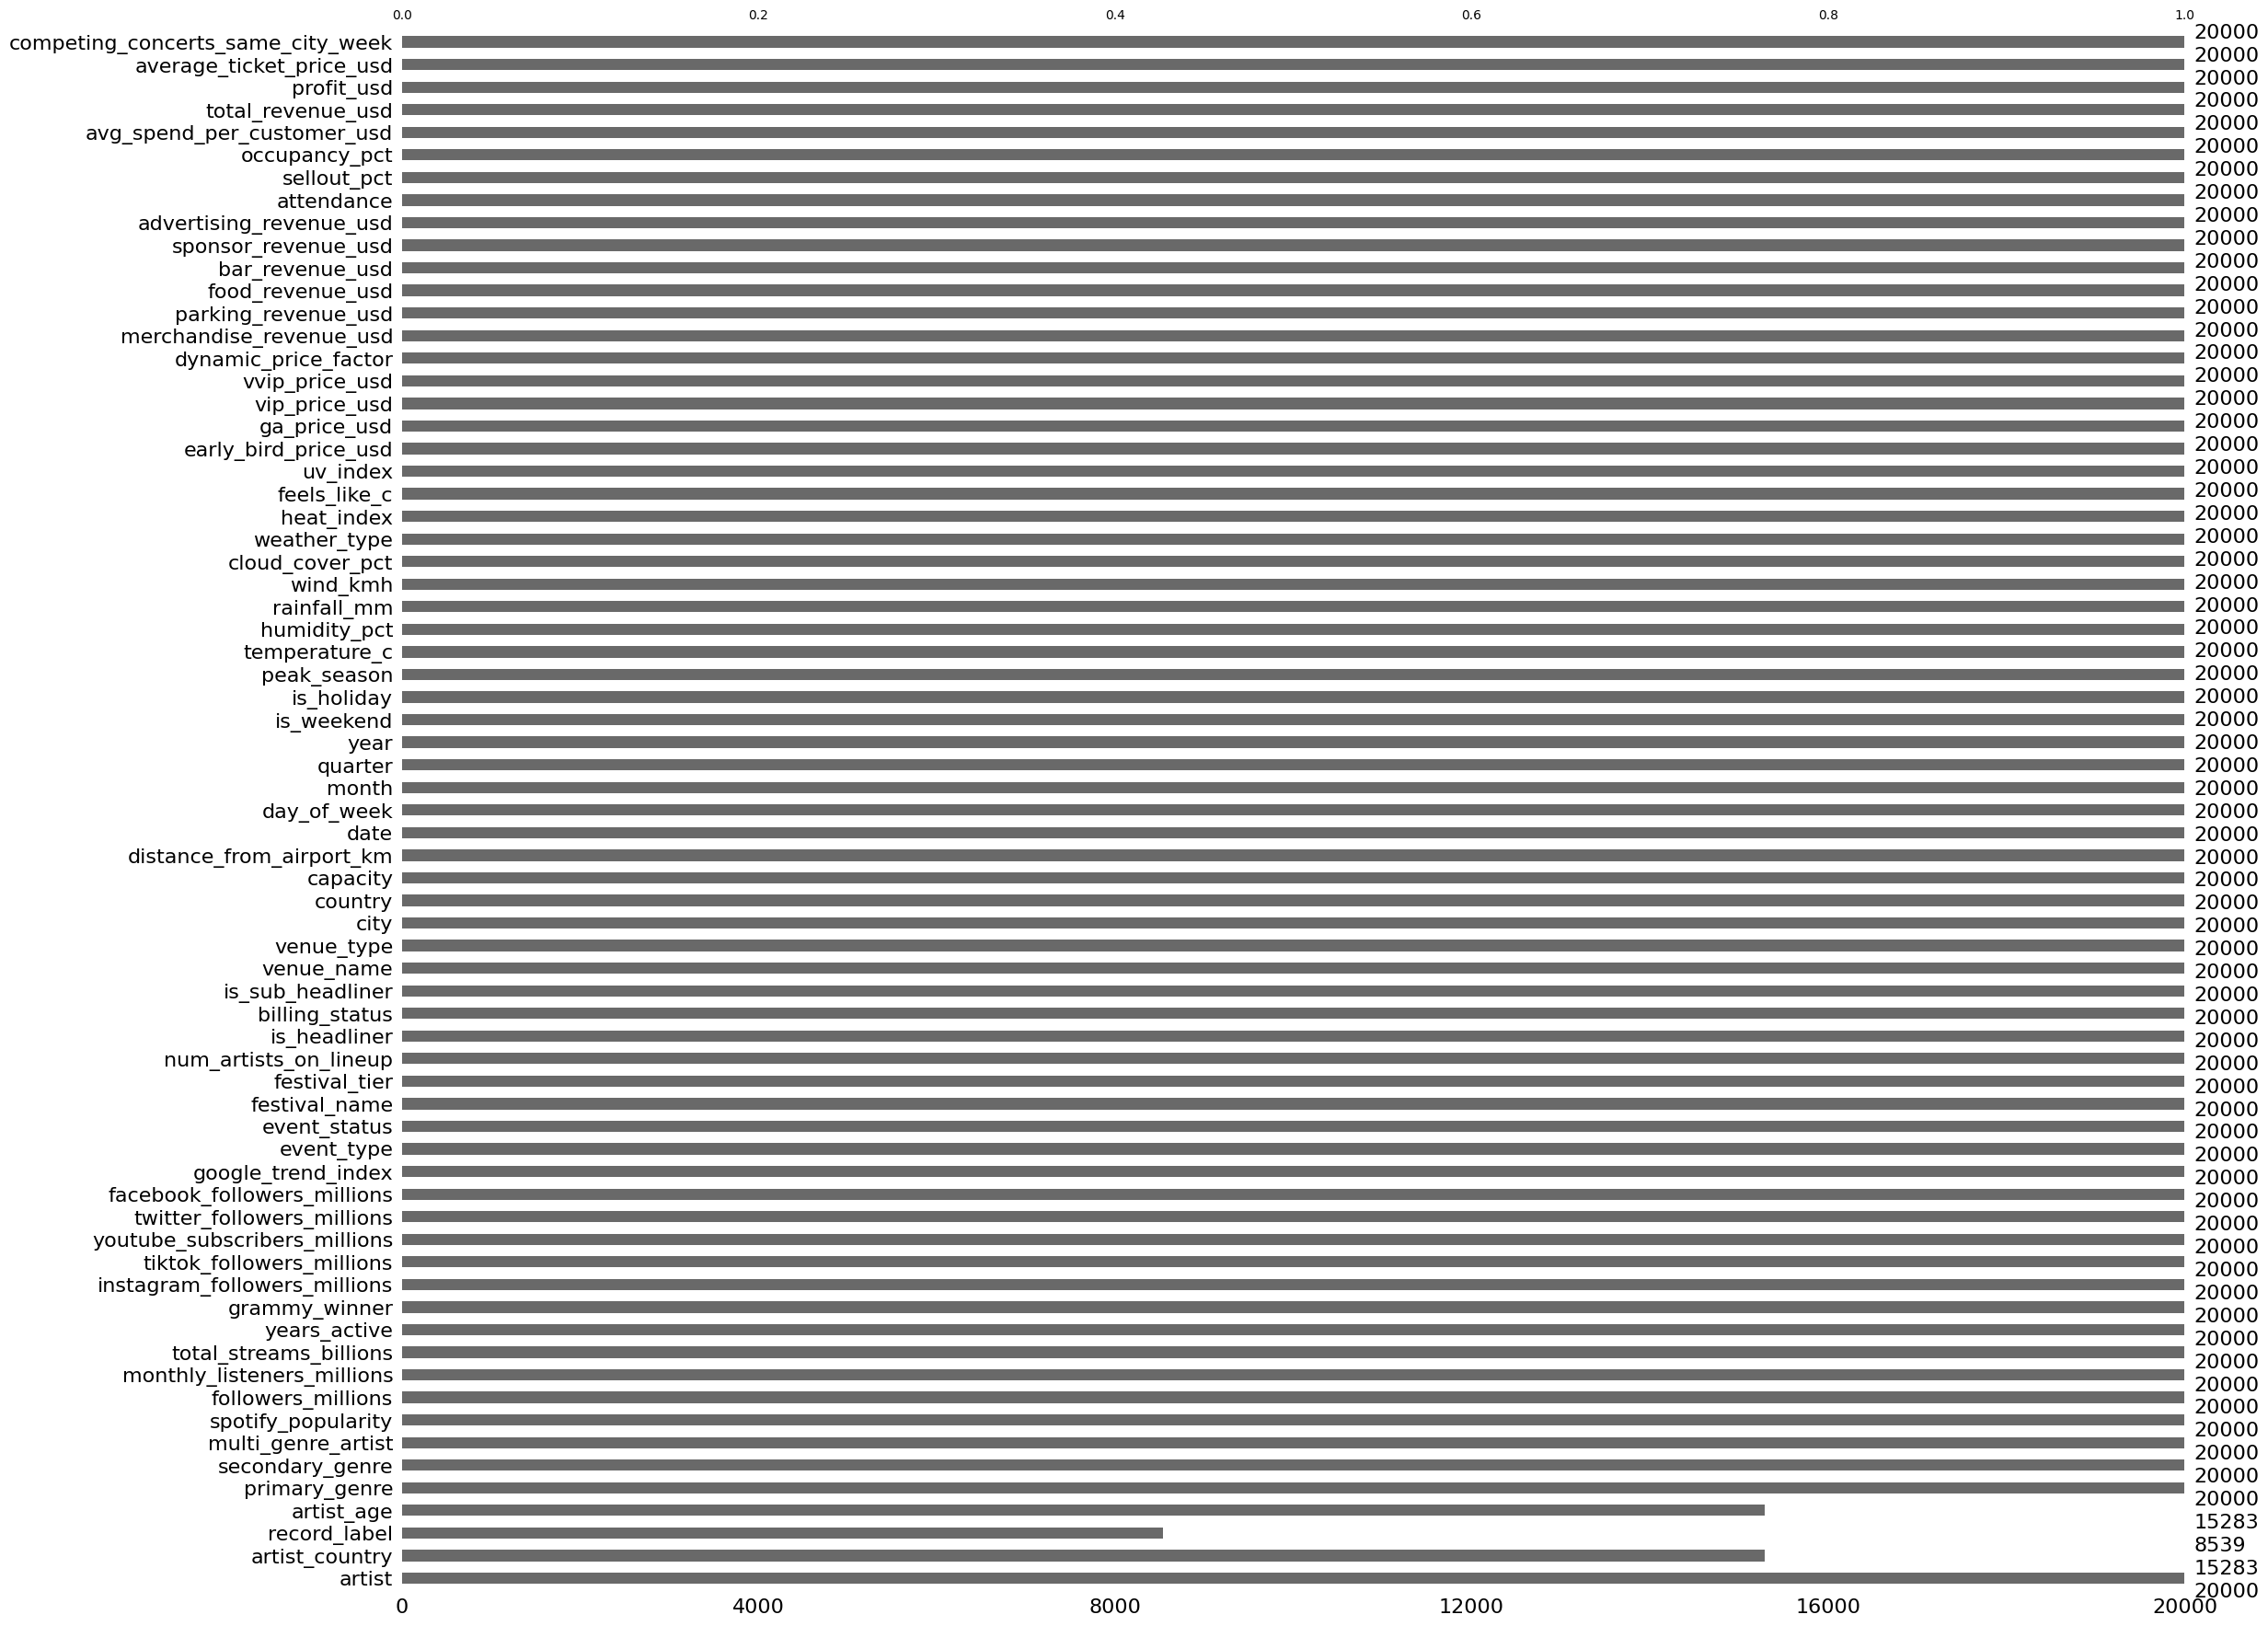

In [21]:
msno.bar(df)

In [22]:
df.nunique().sort_values(ascending=False)

total_revenue_usd          19266
profit_usd                 19265
merchandise_revenue_usd    19262
bar_revenue_usd            19260
sponsor_revenue_usd        19259
                           ...  
event_status                   2
multi_genre_artist             2
is_weekend                     2
is_holiday                     2
peak_season                    2
Length: 69, dtype: int64

Non of the Column in our Dataset is truely 100% populated with the unique values which indicates that we dont have any unique identifier(i.e. Primary Key) for our dataset.

In [23]:
df.dtypes.value_counts()

float64    32
object     19
int64      18
Name: count, dtype: int64

In [24]:
df["artist"].nunique()

216

In [25]:
df["primary_genre"].value_counts()

primary_genre
EDM                 12139
Pop                  1631
Hip Hop              1448
Rock                  961
Latin                 705
R&B                   625
K-Pop                 543
Country               487
Afrobeats             440
Metal                 368
Alternative Pop       367
Alternative Rock      195
Electronic             91
Name: count, dtype: int64

<Axes: >

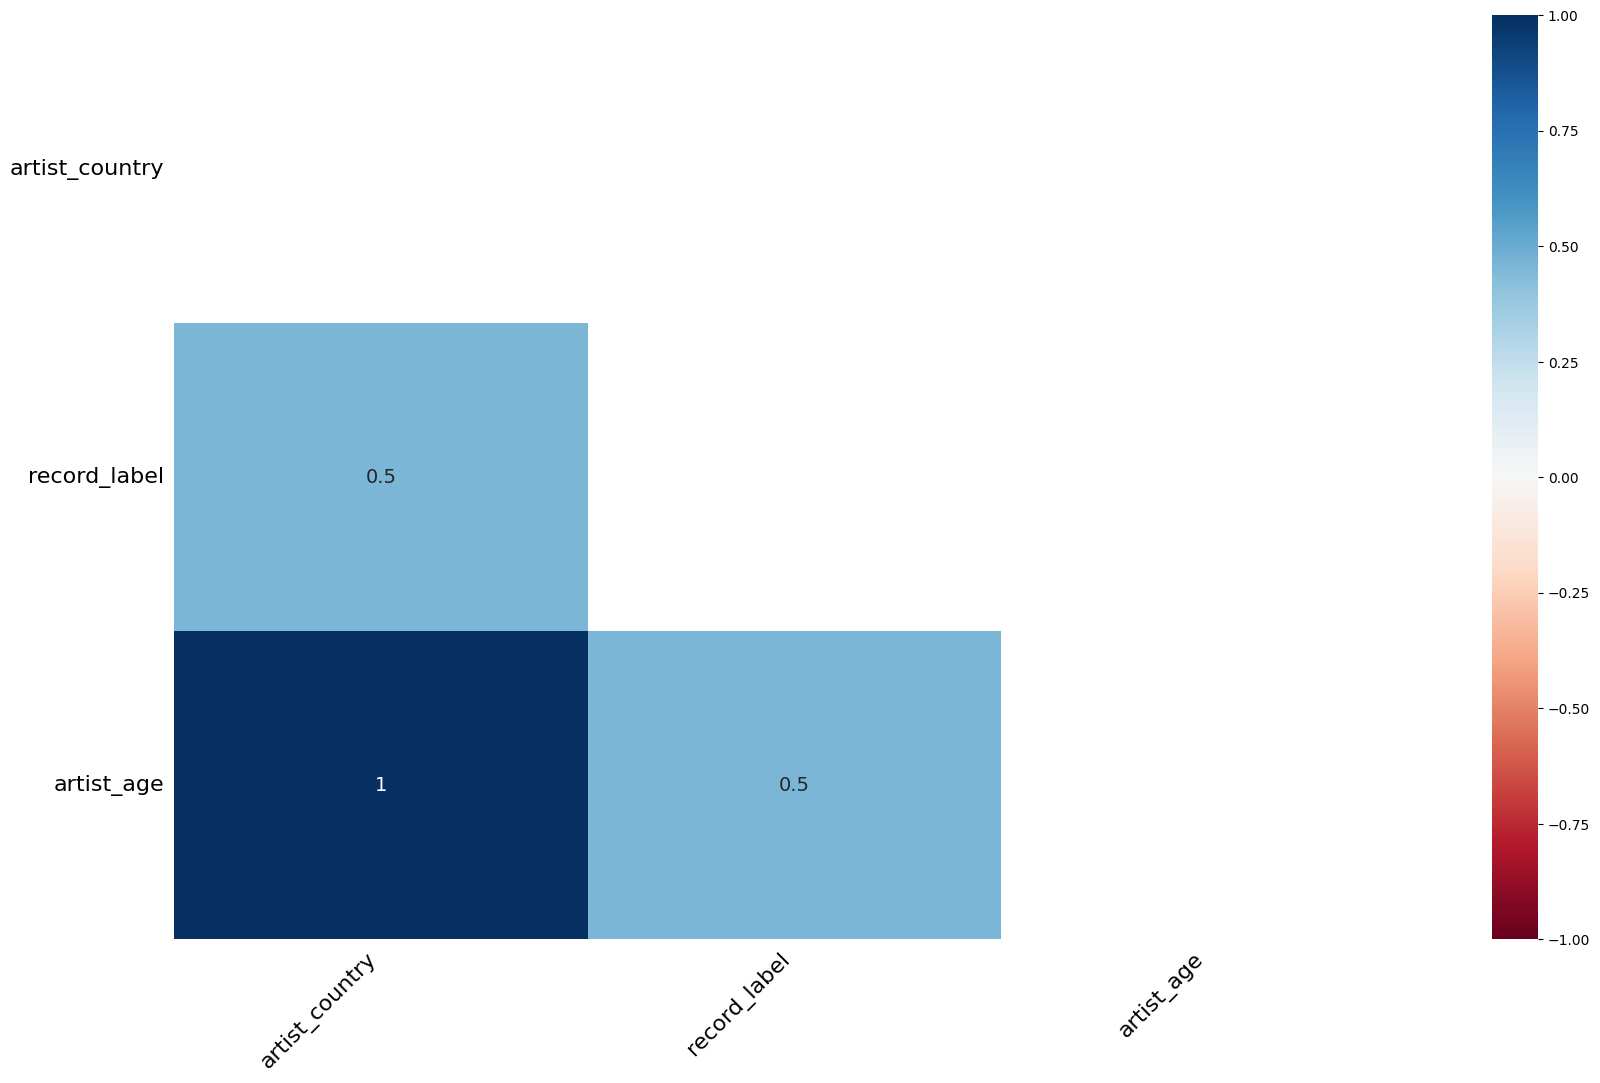

In [26]:
msno.heatmap(df)

In [27]:
df["average_ticket_price_usd"].isnull().sum()

np.int64(0)

# Data Cleaning and Feature Preparation

In [28]:
df.head()

,artist,artist_country,record_label,artist_age,primary_genre,secondary_genre,multi_genre_artist,spotify_popularity,followers_millions,monthly_listeners_millions,...,sponsor_revenue_usd,advertising_revenue_usd,attendance,sellout_pct,occupancy_pct,avg_spend_per_customer_usd,total_revenue_usd,profit_usd,average_ticket_price_usd,competing_concerts_same_city_week
0,Boygenius,USA,NaN,27.0,Alternative Pop,Indie Rock,Yes,19,4.4,3.2,...,38631.49,18736.29,3804,53.5,53.5,63.65,502614.84,190337.59,93.39,1
1,Bonobo,NaN,Independent,NaN,EDM,Downtempo,Yes,60,13.7,12.6,...,515328.15,241142.19,81447,100.0,100.0,89.10,22853464.95,6555703.52,249.68,1
2,Robin Schulz,Germany,NaN,35.0,EDM,Tropical House,Yes,53,10.3,7.9,...,185478.41,41682.27,62954,91.2,86.1,114.95,12300605.62,4008260.29,170.00,4
3,Morgan Wallen,USA,Universal,26.0,Country,Country Pop,Yes,40,14.1,8.4,...,24383.73,9081.63,10240,65.9,61.6,73.57,1814949.72,604707.96,144.85,1
4,Gorgon City,UK,NaN,41.0,EDM,House,Yes,35,2.8,1.9,...,533517.96,143508.01,25979,32.8,30.8,50.66,3166126.70,1289886.74,69.10,0


In [29]:
df['record_label'] = df['record_label'].fillna("Not Available")

In [30]:
df['artist_country'] = df['artist_country'].fillna("Not Available")

Missing artist age values were intentionally retained since imputing the age of an artist would introduce artificial information and could lead to misleading business interpretations

In [31]:
df.head()

,artist,artist_country,record_label,artist_age,primary_genre,secondary_genre,multi_genre_artist,spotify_popularity,followers_millions,monthly_listeners_millions,...,sponsor_revenue_usd,advertising_revenue_usd,attendance,sellout_pct,occupancy_pct,avg_spend_per_customer_usd,total_revenue_usd,profit_usd,average_ticket_price_usd,competing_concerts_same_city_week
0,Boygenius,USA,Not Available,27.0,Alternative Pop,Indie Rock,Yes,19,4.4,3.2,...,38631.49,18736.29,3804,53.5,53.5,63.65,502614.84,190337.59,93.39,1
1,Bonobo,Not Available,Independent,NaN,EDM,Downtempo,Yes,60,13.7,12.6,...,515328.15,241142.19,81447,100.0,100.0,89.10,22853464.95,6555703.52,249.68,1
2,Robin Schulz,Germany,Not Available,35.0,EDM,Tropical House,Yes,53,10.3,7.9,...,185478.41,41682.27,62954,91.2,86.1,114.95,12300605.62,4008260.29,170.00,4
3,Morgan Wallen,USA,Universal,26.0,Country,Country Pop,Yes,40,14.1,8.4,...,24383.73,9081.63,10240,65.9,61.6,73.57,1814949.72,604707.96,144.85,1
4,Gorgon City,UK,Not Available,41.0,EDM,House,Yes,35,2.8,1.9,...,533517.96,143508.01,25979,32.8,30.8,50.66,3166126.70,1289886.74,69.10,0


Missing values were replaced with 'Not Available' instead of imputing the mode because the absence of information may itself carry business significance.

In [113]:
df['date'] = pd.to_datetime(df['date'])

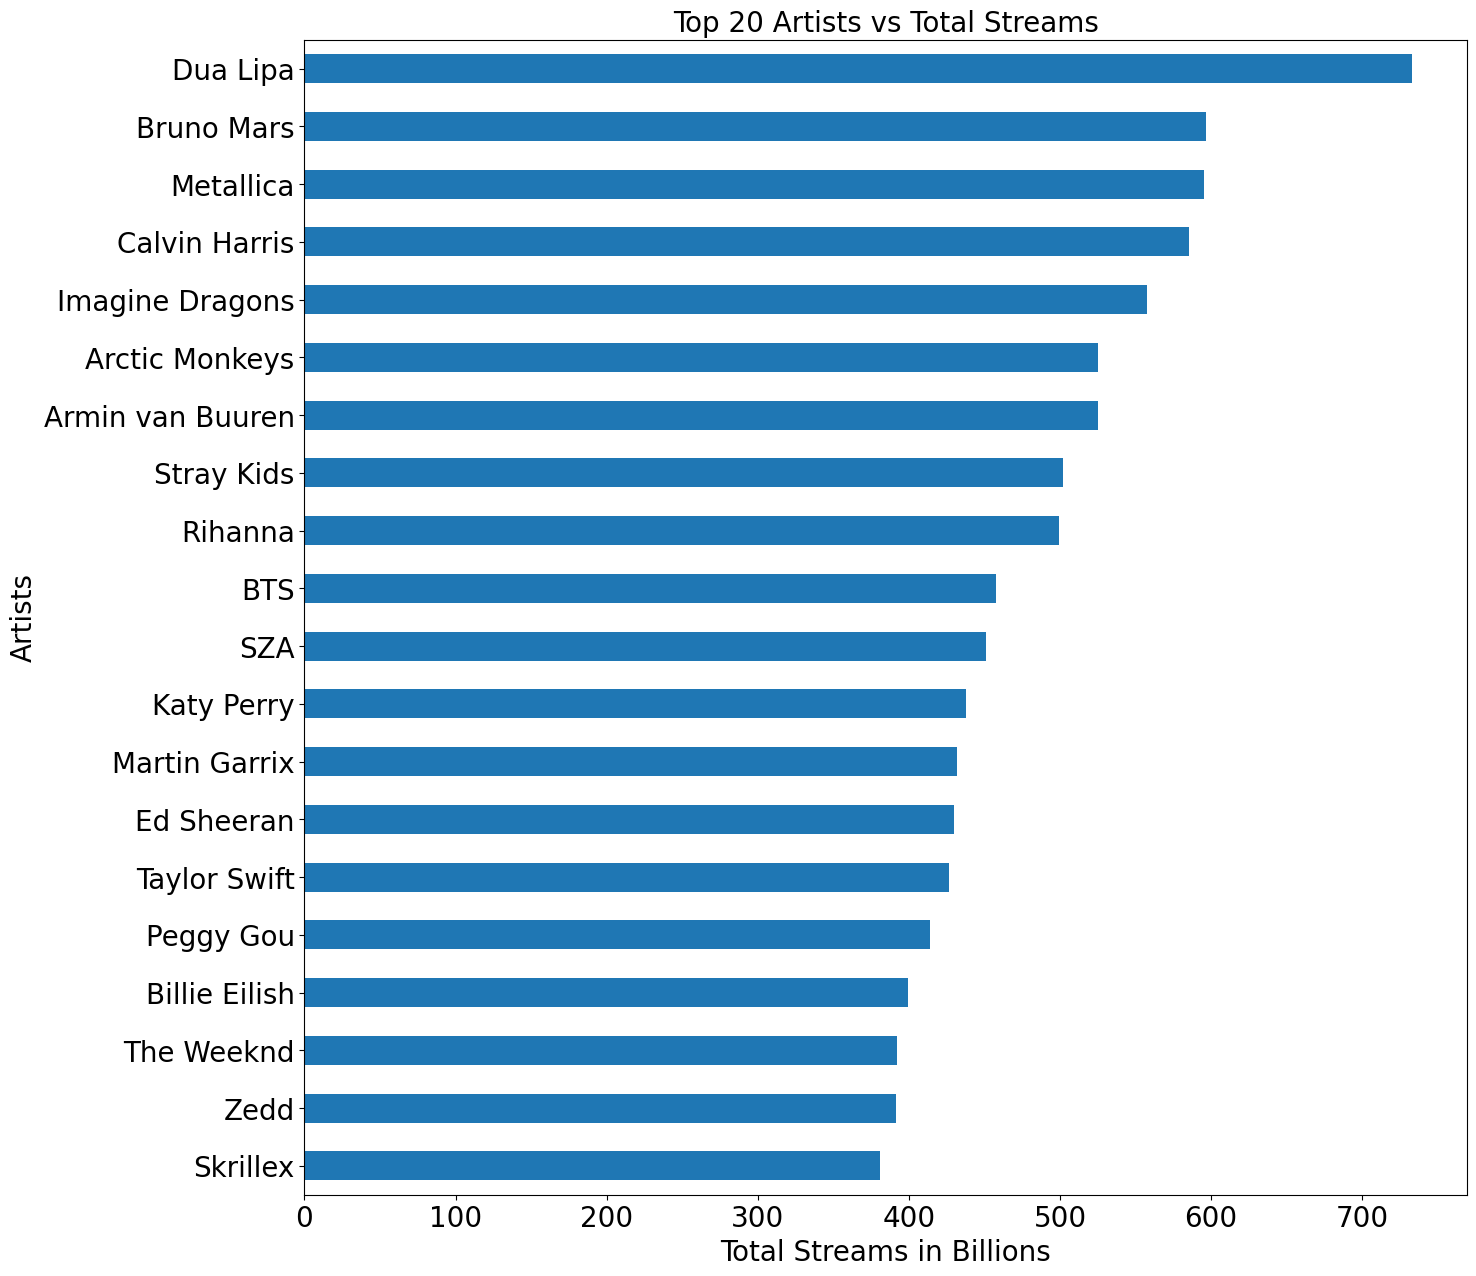

In [32]:
atrist_vs_streams = df.groupby('artist')['total_streams_billions'].sum().sort_values(ascending=True).tail(20)
plt.figure(figsize=(15,15))
atrist_vs_streams.plot(kind='barh')
plt.xlabel("Total Streams in Billions",fontsize=20)
plt.ylabel("Artists",fontsize=20)
plt.title("Top 20 Artists vs Total Streams",fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

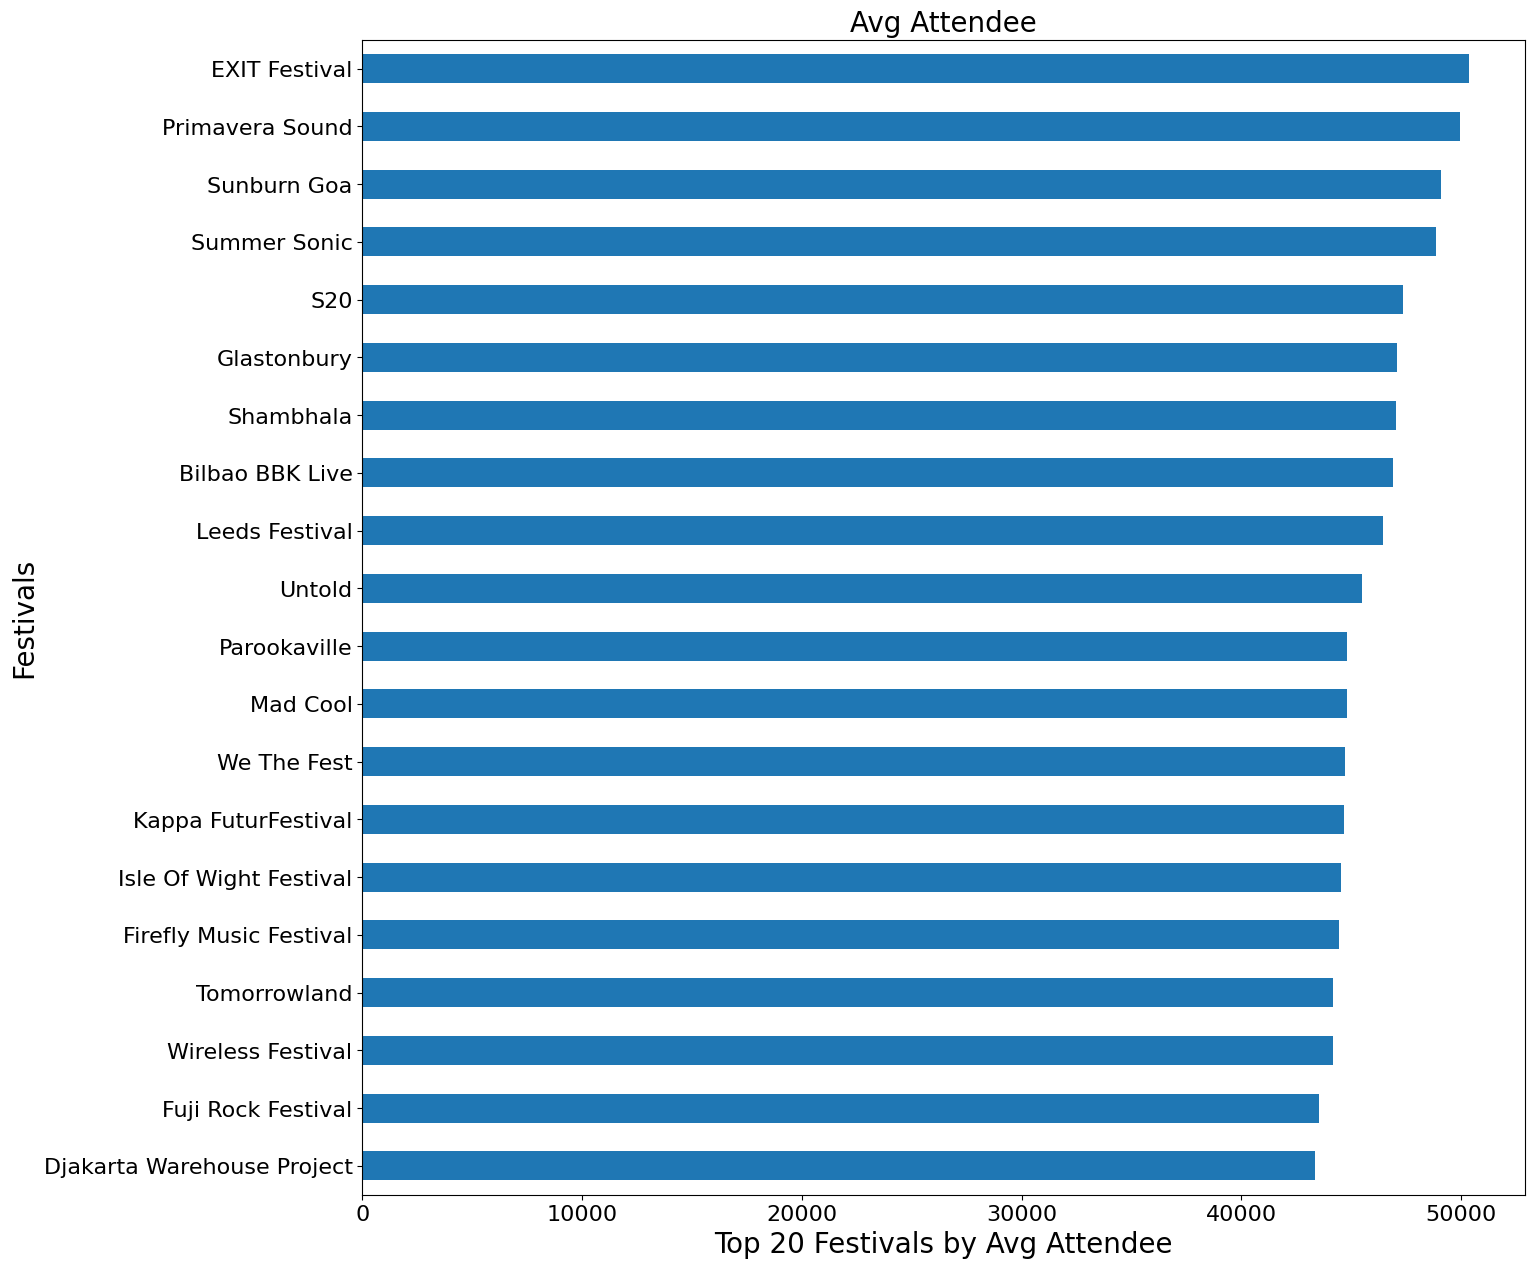

In [33]:
fest_name_attendence = df.groupby('festival_name')['attendance'].mean().sort_values(ascending=True).tail(20)
plt.figure(figsize=(15,15))
fest_name_attendence.plot(kind='barh')
plt.xlabel("Top 20 Festivals by Avg Attendee",fontsize=20)
plt.ylabel("Festivals",fontsize=20)
plt.title("Avg Attendee by Festivals",fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

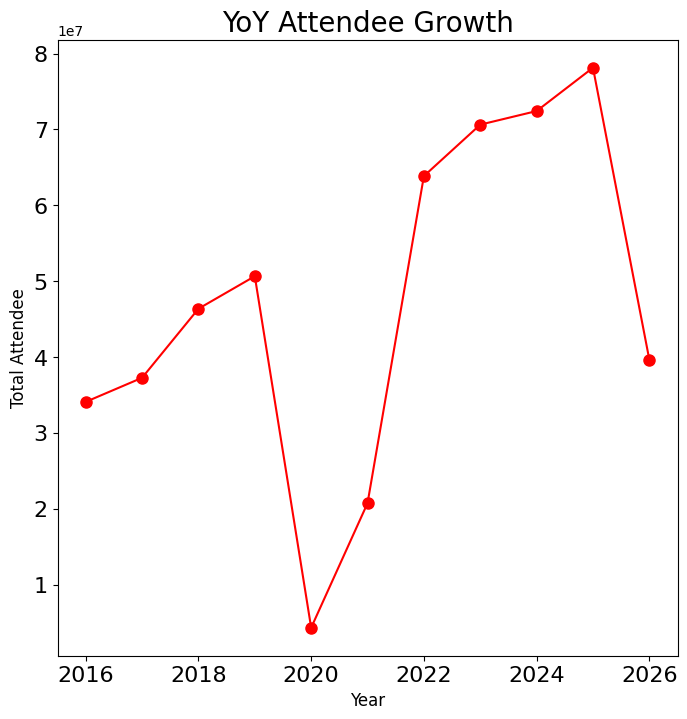

In [39]:
fest_name_attendence = df.groupby('year')['attendance'].sum()
plt.figure(figsize=(8,8))
fest_name_attendence.plot(kind='line',marker='o', markersize=8, color='red', linestyle='-')
plt.xlabel("Year",fontsize=12)
plt.ylabel("Total Attendee",fontsize=12)
plt.title("YoY Attendee Growth",fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

As per our Dataset Here in year 2020 and 2021 we had a sharp fall in the number of attendees attending the concerts that's probably because of the COVID Pandemic and post that we can already see that we have a sharp up trend indicating people have come out to attend the festivals and concerts more frequently post COVID and even if we try to compare pre and post Pandemic era we can see a huge shift in audiance coming out for the Music Festivals

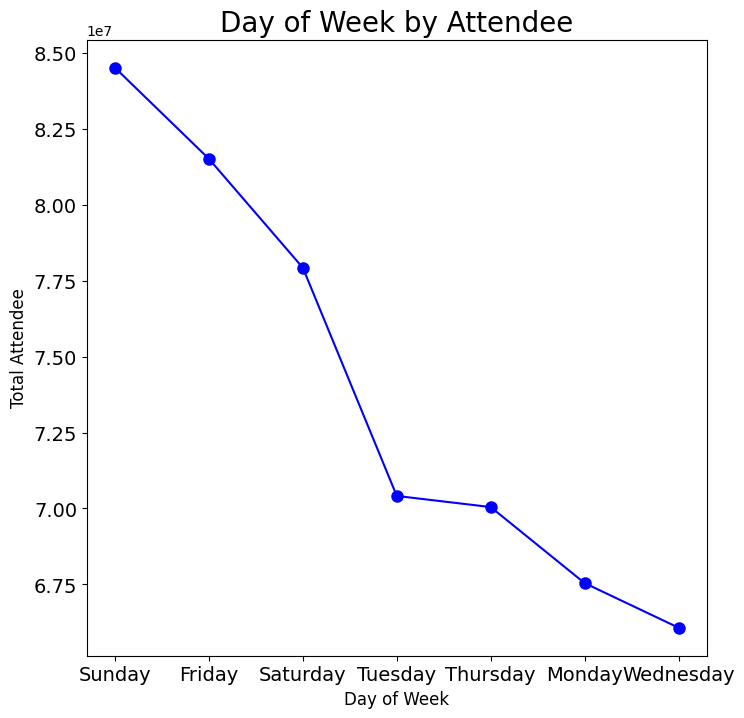

In [38]:
day_of_week_attendence = df.groupby('day_of_week')['attendance'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,8))
day_of_week_attendence.plot(kind='line',marker='o', markersize=8, color='blue', linestyle='-')
plt.xlabel("Day of Week",fontsize=12)
plt.ylabel("Total Attendee",fontsize=12)
plt.title("Day of Week by Attendee",fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

From our Dataset we can clearly see that Friday, Saturday and Sunday together contribute the highest cumulative attendance, suggesting event organizers strategically schedule concerts during periods of higher audience availability.

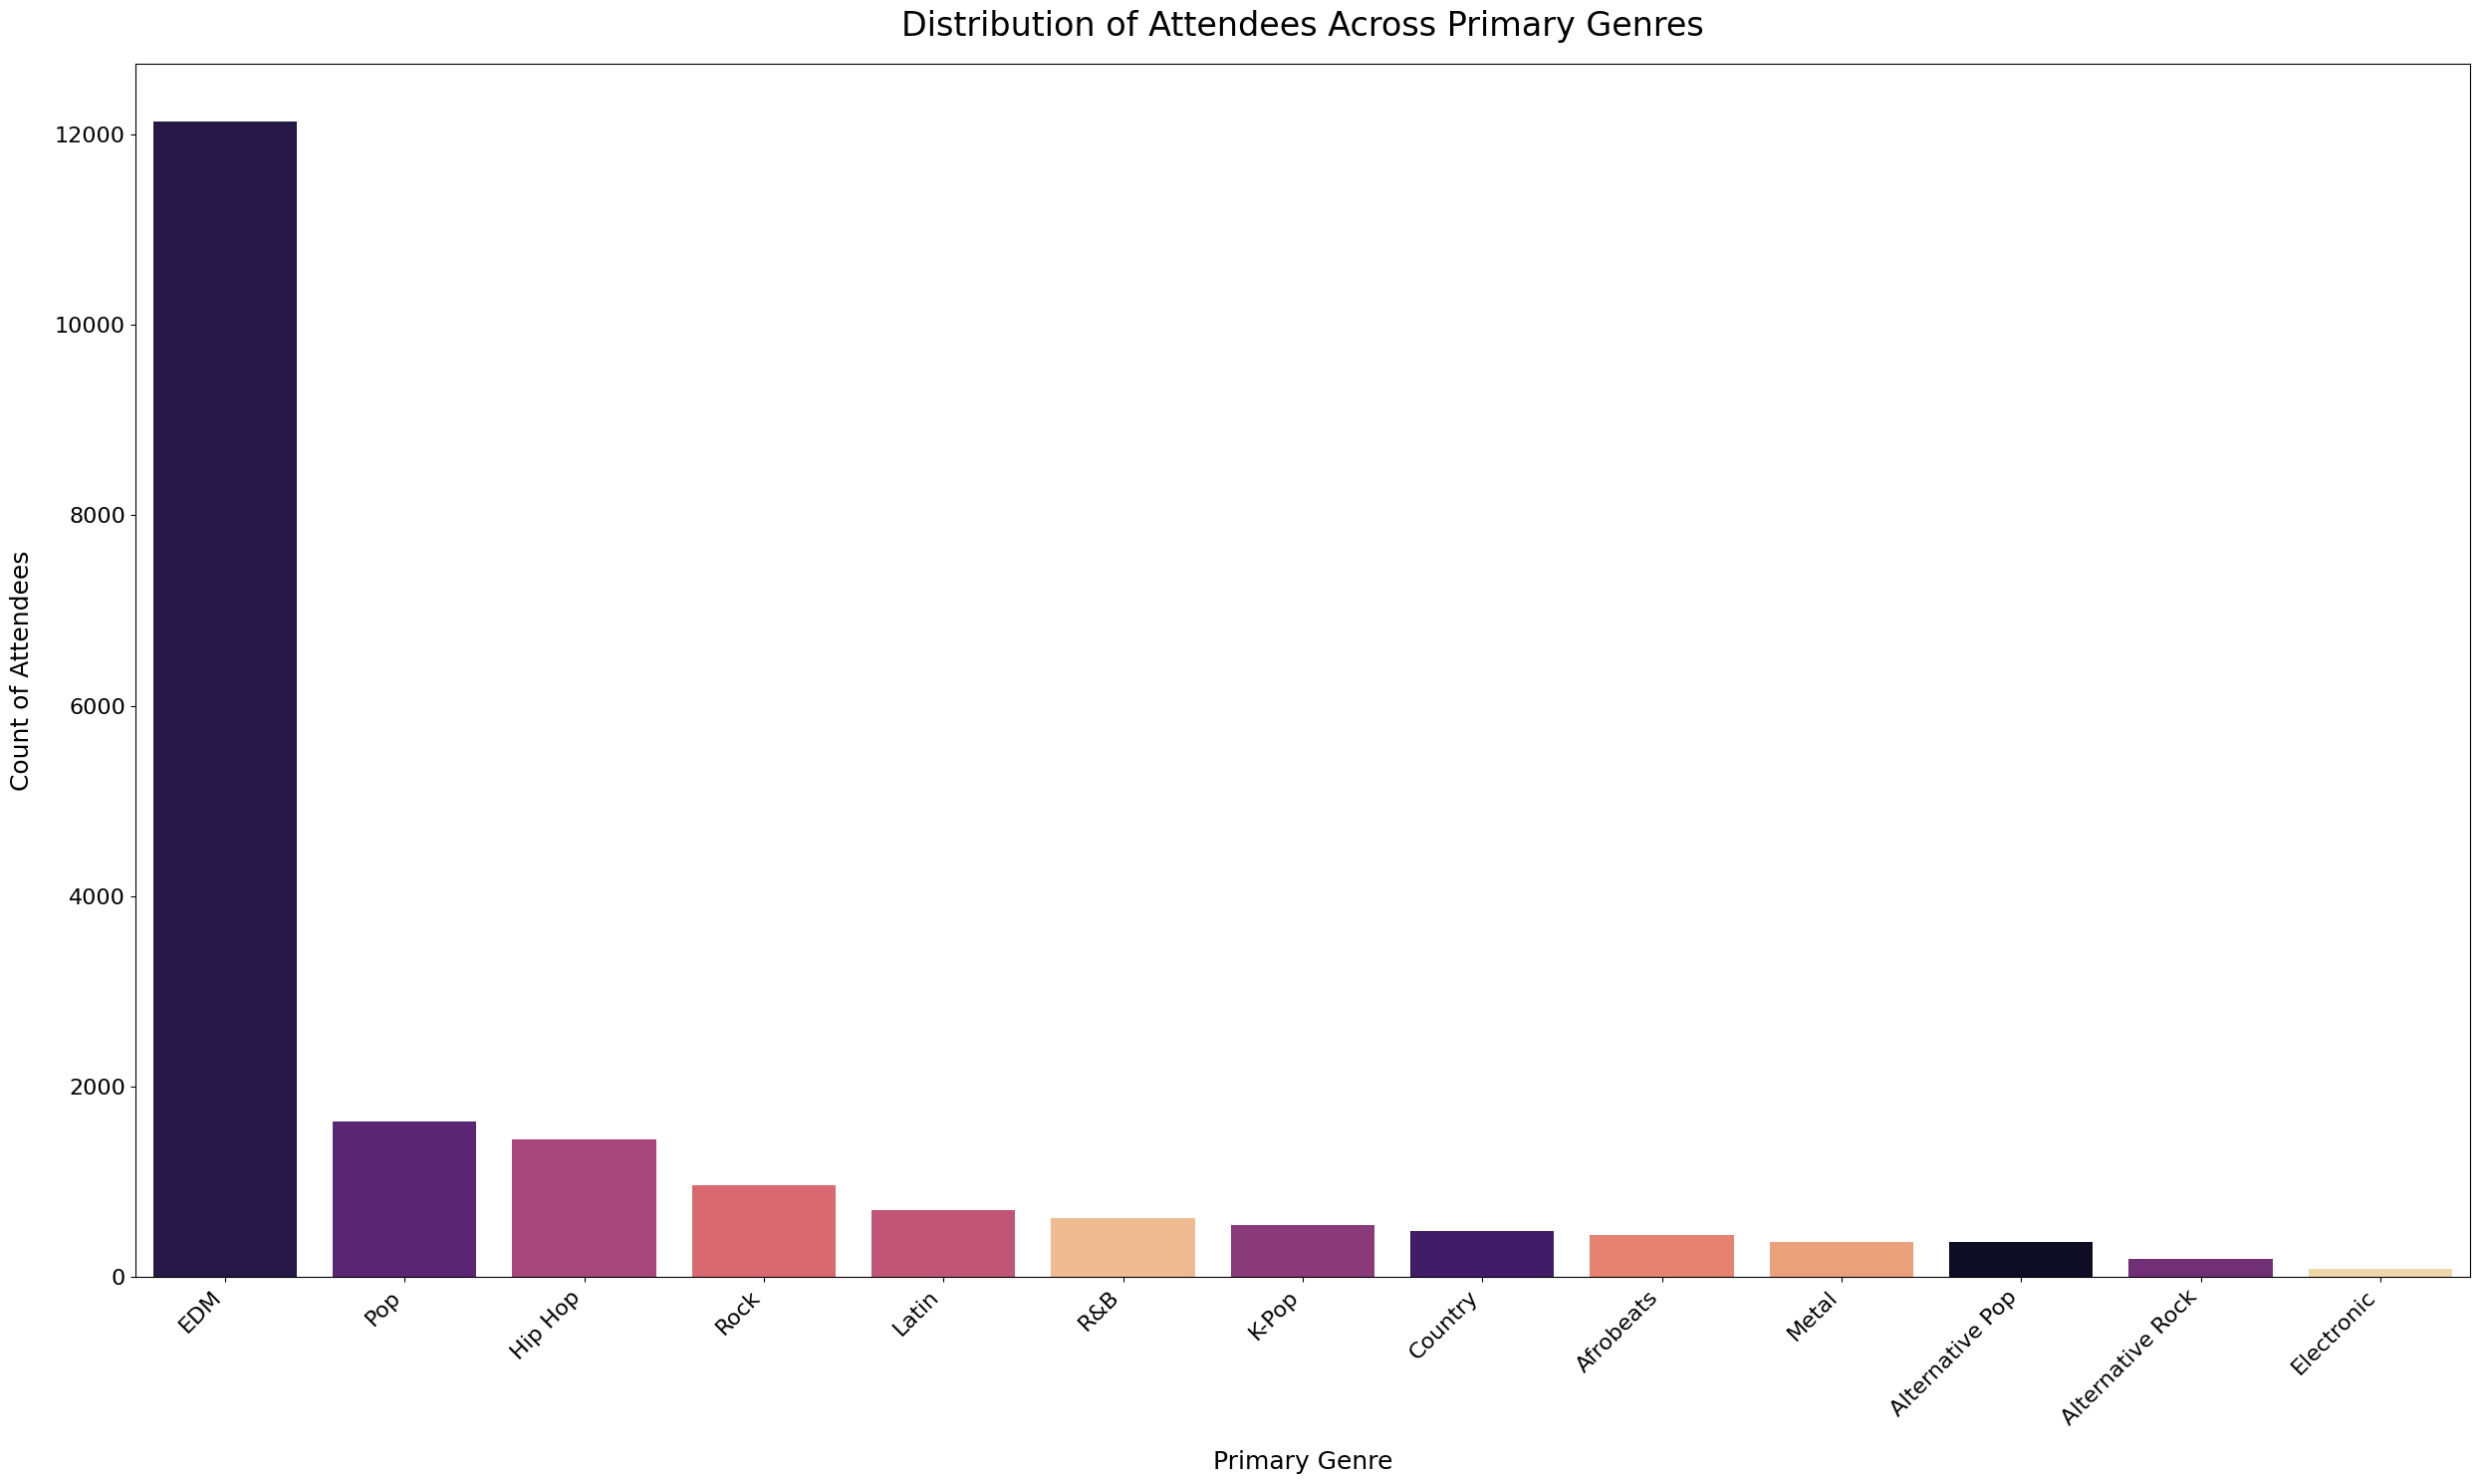

In [155]:
high_to_low = df['primary_genre'].value_counts().index
plt.figure(figsize=(25, 15))
sns.countplot(data=df,x='primary_genre',palette='magma',order=high_to_low,hue='primary_genre')
plt.title("Distribution of Attendees Across Primary Genres", fontsize=24, pad=20)
plt.xlabel("Primary Genre", fontsize=18, labelpad=15)
plt.ylabel("Count of Attendees", fontsize=18, labelpad=15)
plt.xticks(fontsize=16, rotation=45, ha='right')
plt.yticks(fontsize=16)
plt.tight_layout() 
plt.show()

Within this dataset, EDM represents the largest proportion of recorded concert events.

C:\Users\91875\AppData\Local\Temp\ipykernel_2344\4203652562.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['secondary_genre'],palette='plasma',order=sec_genre)


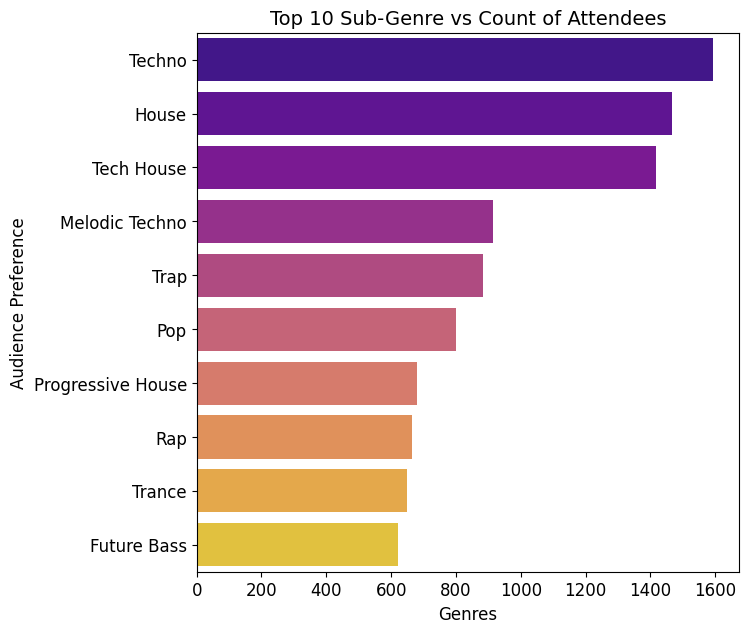

In [151]:
sec_genre = df['secondary_genre'].value_counts().head(10).index
plt.figure(figsize=(7,7))
sns.countplot(df['secondary_genre'],palette='plasma',order=sec_genre)
plt.xlabel("Genres", fontsize=12)
plt.ylabel("Audience Preference", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Top 10 Sub-Genre vs Count of Attendees", fontsize=14)
plt.show()

The dataset reveals that Techno is the most preferred electronic sub-genre, followed by House and Tech House. Interestingly, while EDM dominates live concerts, global streaming charts are still topped by mainstream pop artists like Dua Lipa and Bruno Mars.

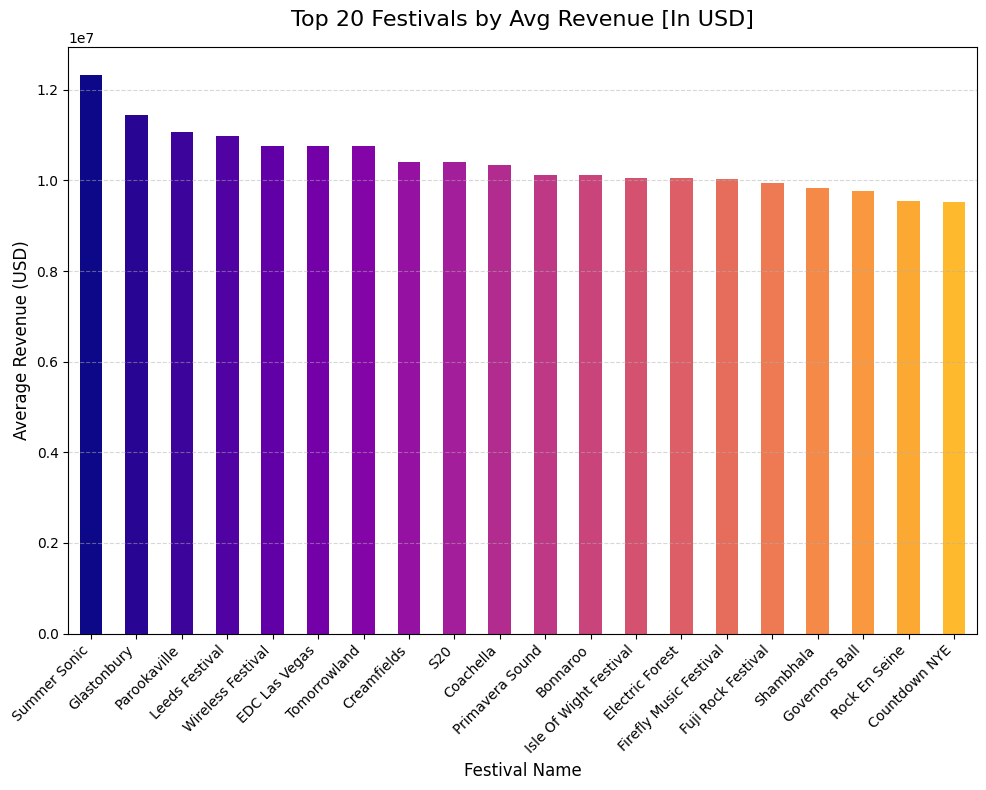

In [158]:
festival_by_avg_revenue = df.groupby('festival_name')['total_revenue_usd'].mean().sort_values(ascending=False).head(20)
colors = plt.colormaps['plasma'](np.linspace(0, 0.85, len(festival_by_avg_revenue)))
plt.figure(figsize=(10,8))
festival_by_avg_revenue.plot(kind='bar', color=colors)
plt.title("Top 20 Festivals by Avg Revenue [In USD]", fontsize=16, pad=15)
plt.xlabel("Festival Name", fontsize=12)
plt.ylabel("Average Revenue (USD)", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

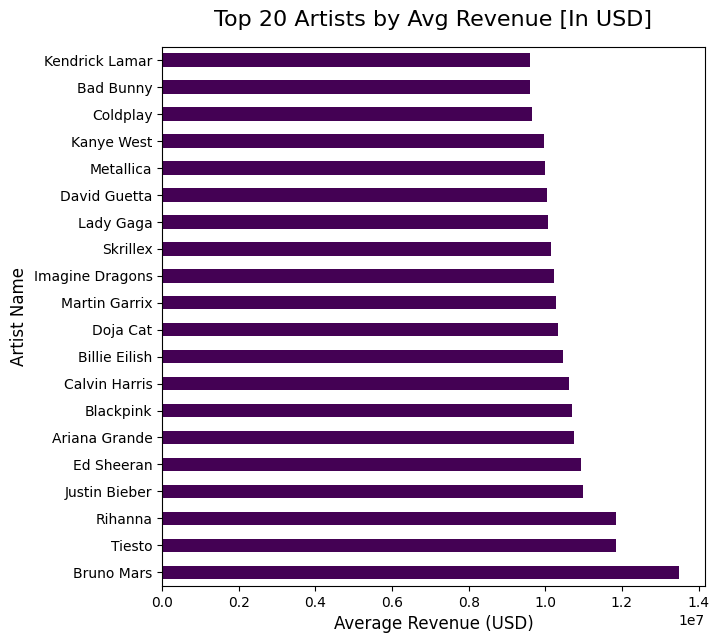

In [139]:
festival_by_avg_revenue = df.groupby('artist')['total_revenue_usd'].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(7,7))
festival_by_avg_revenue.plot(kind='barh', colormap='viridis')
plt.title("Top 20 Artists by Avg Revenue [In USD]", fontsize=16, pad=15)
plt.xlabel("Average Revenue (USD)", fontsize=12)
plt.ylabel("Artist Name", fontsize=12)
plt.show()

As per our Dataset Bruno Mars emerges as the Top Revenue generating Artist followed by Rihanna and Tiesto, we also need to keep this in mind that all these artists are from pop genre except Tiesto but our data had shown that edm is still the most Crowd Pulling Genre. Which might indicate that Combining Multiple EDM Artist might be a better Revenue Generating Stream rather then just signing one POP Artist

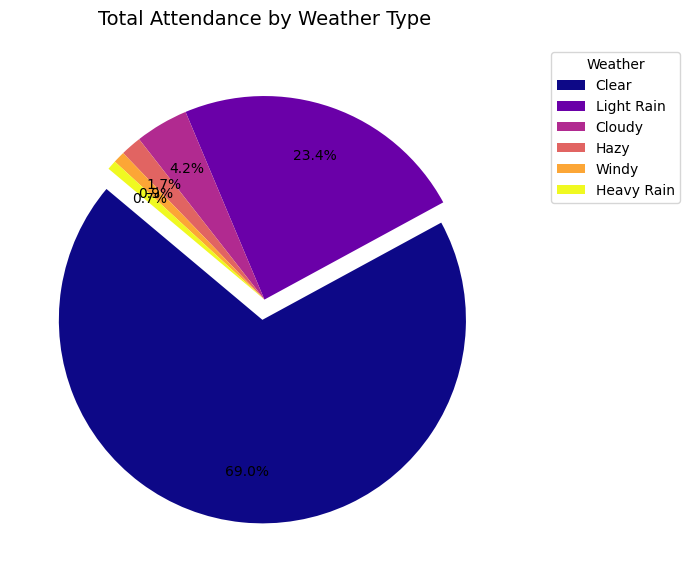

In [134]:
attendee_by_weather = df.groupby('weather_type')['attendance'].sum().sort_values(ascending=False)
explode_values = [0.1 if i == 0 else 0 for i in range(len(attendee_by_weather))]
plt.figure(figsize=(7,7))
attendee_by_weather.plot(kind='pie', autopct='%1.1f%%', pctdistance=0.75,colormap='plasma', explode=explode_values,
                             labels=None,startangle=140)
plt.legend(labels=attendee_by_weather.index, title="Weather", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel('')
plt.tight_layout()
plt.title("Total Attendance by Weather Type", fontsize=14, pad=15)
plt.show()

From our Dataset we can clearly see that Audience prefers Clear Weather and it also makes sense that while in concerts rains are its biggest enemies, but it is also being observed that few people like going to concerts even in light rains and chill weather.

In [75]:
pd.set_option('display.max_rows',None)
pd.crosstab(df['artist'],df['billing_status']).sort_values(by='Headliner',ascending=False)

billing_status,Headliner,Opening Act,Sub-Headliner,Support Act
artist,,,,
Eminem,94,0,11,1
Post Malone,94,0,5,2
Martin Garrix,92,0,13,4
Doja Cat,92,0,11,3
Metallica,91,0,10,2
Imagine Dragons,89,0,9,4
Armin van Buuren,89,0,10,2
Rihanna,89,0,10,3
Tiesto,88,0,8,3


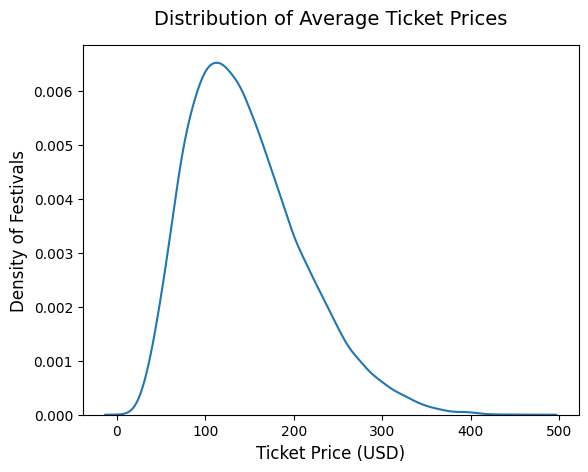

In [140]:
sns.kdeplot(df['average_ticket_price_usd'])
plt.title("Distribution of Average Ticket Prices", fontsize=14, pad=15)
plt.xlabel("Ticket Price (USD)", fontsize=12)
plt.ylabel("Density of Festivals", fontsize=12)
plt.show()

Cancelled events have been retained during EDA to represent real-world operational outcomes. However, these observations will be excluded during predictive modeling where appropriate

Average ticket prices exhibit a positively skewed distribution. Most concerts are priced between $80–180, while premium events represent a relatively small proportion of the dataset.

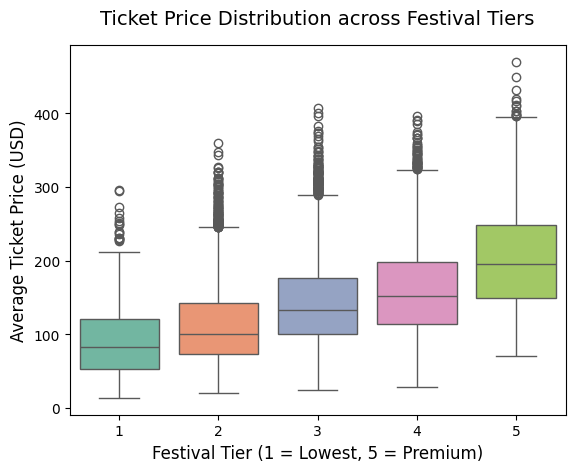

In [143]:
sns.boxplot(x=df['festival_tier'],y=df['average_ticket_price_usd'],data=df,palette='Set2',hue='festival_tier',legend=False)
plt.title("Ticket Price Distribution across Festival Tiers", fontsize=14, pad=15)
plt.xlabel("Festival Tier (1 = Lowest, 5 = Premium)", fontsize=12)
plt.ylabel("Average Ticket Price (USD)", fontsize=12)
plt.show()

Higher festival tiers consistently command higher ticket prices, with both the median price and price variability increasing across festival tiers. Premium festivals therefore follow a clear value-based pricing strategy.

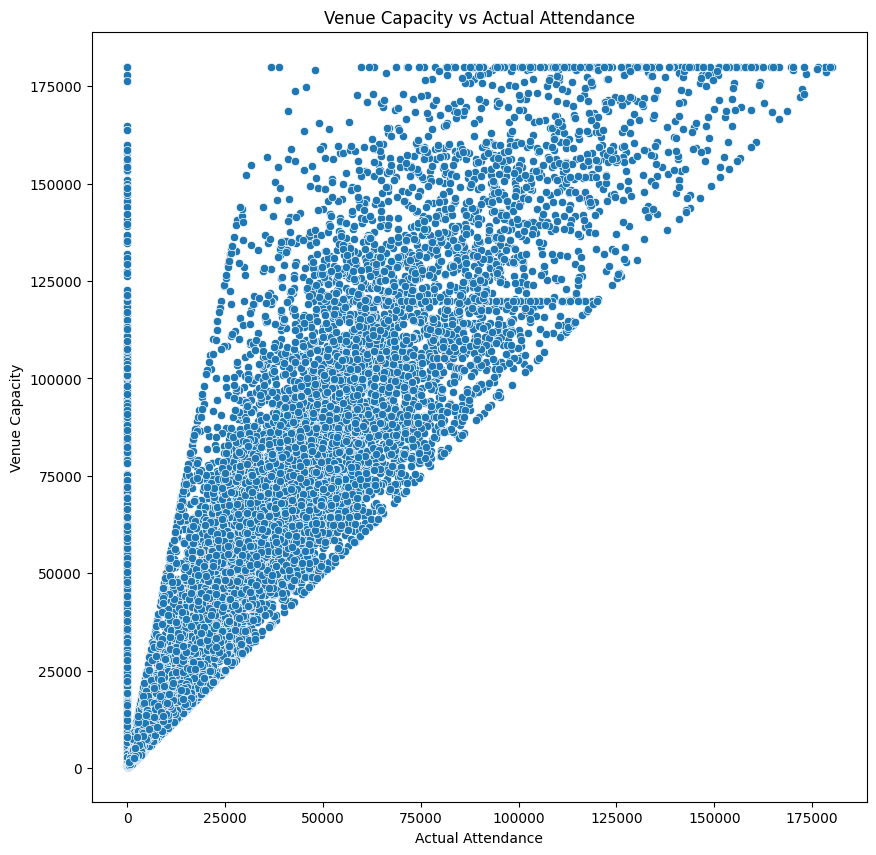

In [83]:
plt.figure(figsize=(10,10))
sns.scatterplot(x=df['attendance'],y=df['capacity'],data=df)
plt.xlabel("Actual Attendance")
plt.ylabel("Venue Capacity")
plt.title("Venue Capacity vs Actual Attendance")
plt.show()

The scatter plot demonstrates a strong positive relationship between venue capacity and actual attendance. As venue capacity increases, the number of attendees also increases, indicating that larger venues are generally selected for events with higher expected demand. However, the noticeable spread in attendance across similar venue capacities suggests that capacity alone does not determine event success. Factors such as artist popularity, ticket pricing, weather conditions, festival reputation, and event timing also play a significant role in influencing audience turnout.

In [85]:
df['Covid'] = df['year'].apply(lambda x: 'Post-Covid'if x >= 2022 else 'Covid' if  2020 <= x <= 2021 else 'Pre-Covid')

In [86]:
df.head()

,artist,artist_country,record_label,artist_age,primary_genre,secondary_genre,multi_genre_artist,spotify_popularity,followers_millions,monthly_listeners_millions,...,advertising_revenue_usd,attendance,sellout_pct,occupancy_pct,avg_spend_per_customer_usd,total_revenue_usd,profit_usd,average_ticket_price_usd,competing_concerts_same_city_week,Covid
0,Boygenius,USA,Not Available,27.0,Alternative Pop,Indie Rock,Yes,19,4.4,3.2,...,18736.29,3804,53.5,53.5,63.65,502614.84,190337.59,93.39,1,Pre-Covid
1,Bonobo,Not Available,Independent,NaN,EDM,Downtempo,Yes,60,13.7,12.6,...,241142.19,81447,100.0,100.0,89.10,22853464.95,6555703.52,249.68,1,Post-Covid
2,Robin Schulz,Germany,Not Available,35.0,EDM,Tropical House,Yes,53,10.3,7.9,...,41682.27,62954,91.2,86.1,114.95,12300605.62,4008260.29,170.00,4,Post-Covid
3,Morgan Wallen,USA,Universal,26.0,Country,Country Pop,Yes,40,14.1,8.4,...,9081.63,10240,65.9,61.6,73.57,1814949.72,604707.96,144.85,1,Pre-Covid
4,Gorgon City,UK,Not Available,41.0,EDM,House,Yes,35,2.8,1.9,...,143508.01,25979,32.8,30.8,50.66,3166126.70,1289886.74,69.10,0,Post-Covid


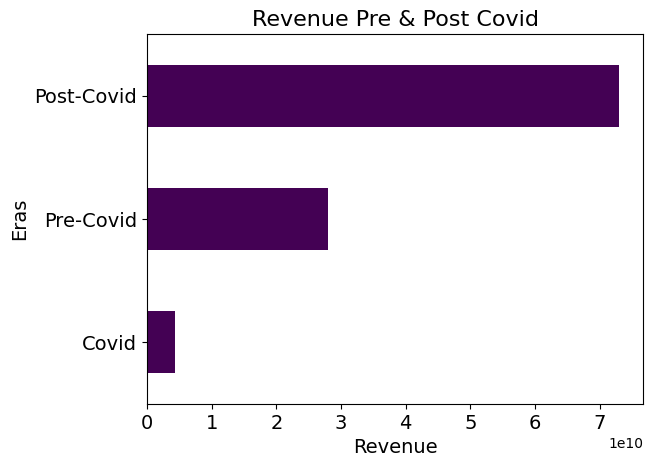

In [101]:
covid_analysis_by_revenue = df.groupby("Covid")['total_revenue_usd'].sum().sort_values(ascending=True)
covid_analysis_by_revenue.plot(kind='barh',colormap='viridis')
plt.ylabel("Eras",fontsize=14)
plt.xlabel("Revenue",fontsize=14)
plt.title("Revenue Pre & Post Covid",fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

The COVID period witnessed a substantial decline in attendance and revenue compared to the pre-pandemic period. However, post-pandemic years demonstrated a strong recovery, with both attendance and revenue surpassing pre-COVID levels. This suggests a resurgence in demand for live entertainment and indicates that the concert industry has not only recovered but expanded beyond its pre-pandemic performance.

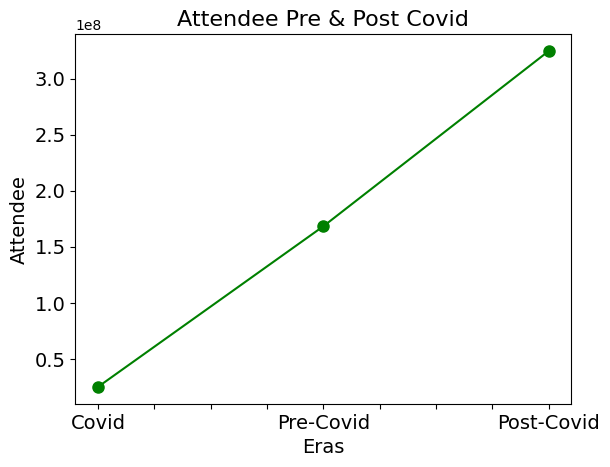

In [111]:
covid_analysis_by_attendence = df.groupby('Covid')['attendance'].sum().sort_values(ascending=True)
covid_analysis_by_attendence.plot(kind='line',marker='o', markersize=8, color='green', linestyle='-')
plt.ylabel("Attendee",fontsize=14)
plt.xlabel("Eras",fontsize=14)
plt.title("Attendee Pre & Post Covid",fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Concert attendance remained stable during 2018–2019, declined sharply in 2020–2021 due to COVID-19 restrictions, and recovered strongly from 2022 onwards. By 2024–2026, attendance exceeded pre-pandemic levels, indicating renewed consumer interest in live events.

In [159]:
df.to_csv("concert_dataset_cleaned.csv", index=False)